In [10]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import cyltransf as ct
from scipy import odr

file_dir = "data100ns-2008"
output_dir = "output"

u_mean = md.Universe(file_dir + "/md_1.tpr", output_dir + "/md_1_mean.xtc")
chains = u_mean.select_atoms("protein").fragments

In [43]:
mol = 1
molecule = chains[3*mol:3*mol + 3]
molecule_coords = (molecule[0] + molecule[1]+ molecule[2]).positions

len_mol = (molecule_coords[:,2].max() - molecule_coords[:,2].min()) / 10

molecule_mean_filt = ct.remove_ends(0.5, molecule_coords) / 10

# Cylindrical Coordinates
rad_mol, phi_mol, z_mol = ct.cyl_proj(molecule_mean_filt)

#rad_mol, phi_mol, z_mol = ct.cyl_proj(molecule_coords)

For orthogonal regression SciPy

In [12]:
def model_fn(p, x):
    # Coefficients p, x data
    m, c = p
    return m * x + c

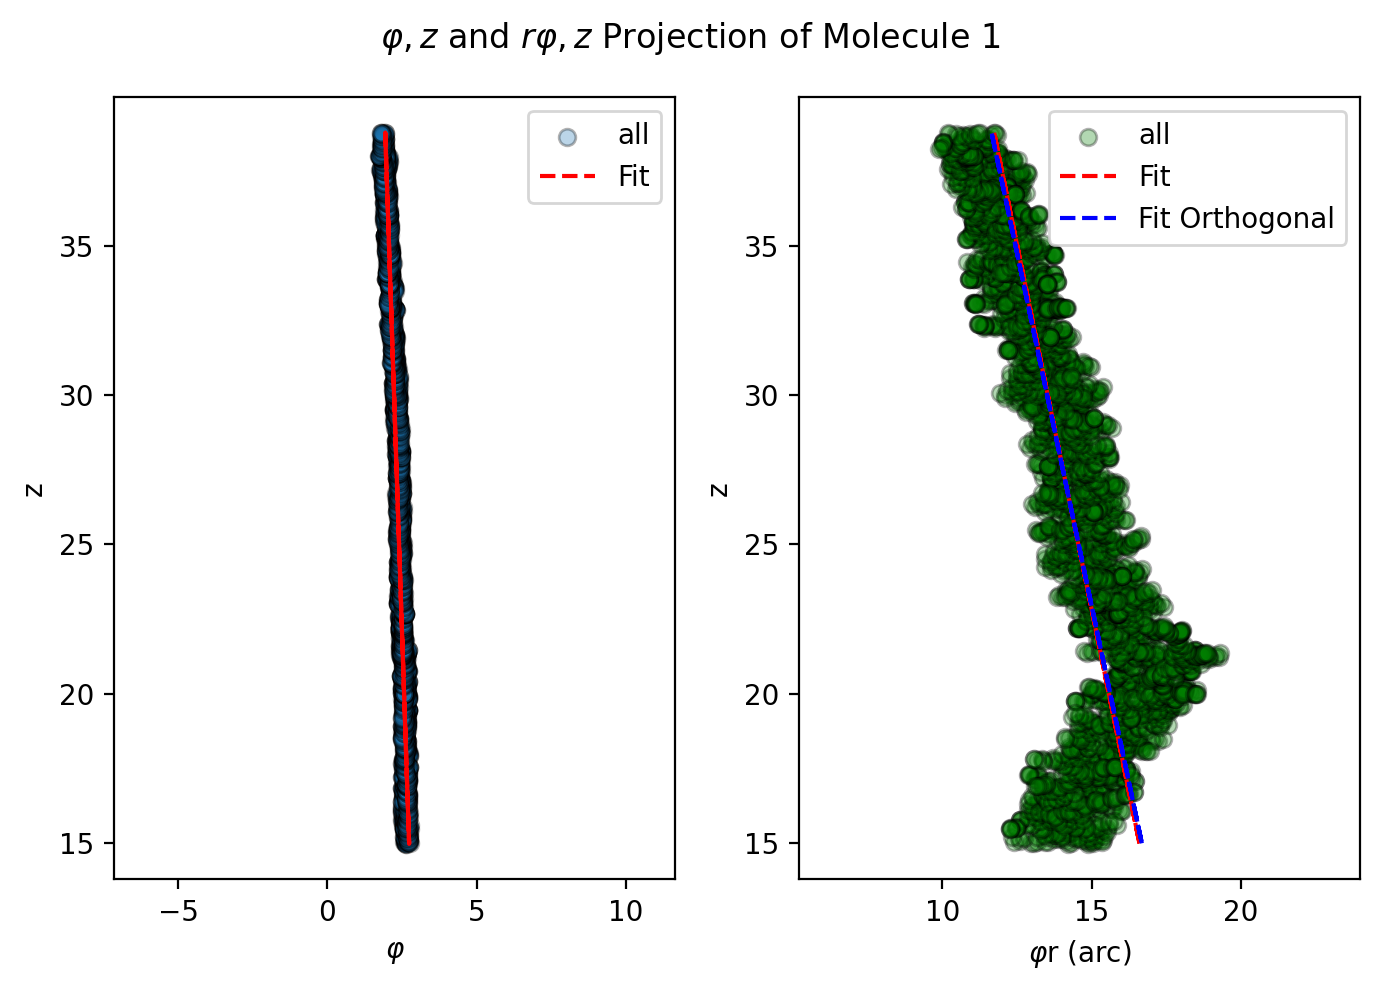

Data of the Molecule:
Length of the molecule (nm):  47.666
Mean Radius: 6.05408
STD Radius: 0.45370454
Coefficient of determination for fit arc,z: [0.5508931]
Psi (degrees): 11.561535
Ends of the molecule fit (arc, z): (16.60, 14.99) to (11.74, 38.79)


In [44]:
atoms_label = 'all'

arc_mol = rad_mol*phi_mol

fig, ax = plt.subplots(1, 2, figsize=(7,5), dpi=200)

ax[0].scatter(phi_mol, z_mol, alpha=0.3, edgecolor='k', label=atoms_label)
b, m = np.polynomial.polynomial.polyfit(z_mol, phi_mol, 1)
fit = np.polynomial.polynomial.Polynomial((b, m))  
ax[0].plot(fit(z_mol), z_mol, linestyle='dashed', color='r', label='Fit')

ax[0].axis('equal')
ax[0].set_xlabel(r'$\varphi$')
ax[0].set_ylabel(r'z')
ax[0].legend()

ax[1].scatter(arc_mol, z_mol, color='g', alpha=0.3, edgecolor='k', label=atoms_label)
m, b, r2_mol = ct.linfitandr2(z_mol, arc_mol)
fit = np.polynomial.polynomial.Polynomial((b, m))
ax[1].plot(fit(z_mol), z_mol, linestyle='dashed', color='r', label='Fit')
# --- Orthogonal Regression ---
model = odr.Model(model_fn)
data = odr.Data(z_mol, arc_mol)
odr_run = odr.ODR(data, model, beta0=[m+0.1, b+0.5]) # Guess Parameters
res = odr_run.run()
ax[1].plot(model_fn(res.beta, z_mol), z_mol, linestyle='dashed', color='b', label='Fit Orthogonal')

ax[1].axis('equal')
ax[1].set_xlabel(r'$\varphi$r (arc)')
ax[1].set_ylabel(r'z')
ax[1].legend()

plt.suptitle(rf'$\varphi, z$ and $r\varphi, z$ Projection of Molecule {mol}')
plt.tight_layout()
plt.show()

# Data of the molecule
print("Data of the Molecule:")
print("Length of the molecule (nm): ", len_mol)
print("Mean Radius:", np.mean(rad_mol))
print("STD Radius:", np.std(rad_mol))
print("Coefficient of determination for fit arc,z:", r2_mol)
print("Psi (degrees):", np.rad2deg(np.atan(abs(m))))
print("Ends of the molecule fit (arc, z): " + f"({fit(z_mol[0]):.2f}, {z_mol[0]:.2f}) to ({fit(z_mol[-1]):.2f}, {z_mol[-1]:.2f})")

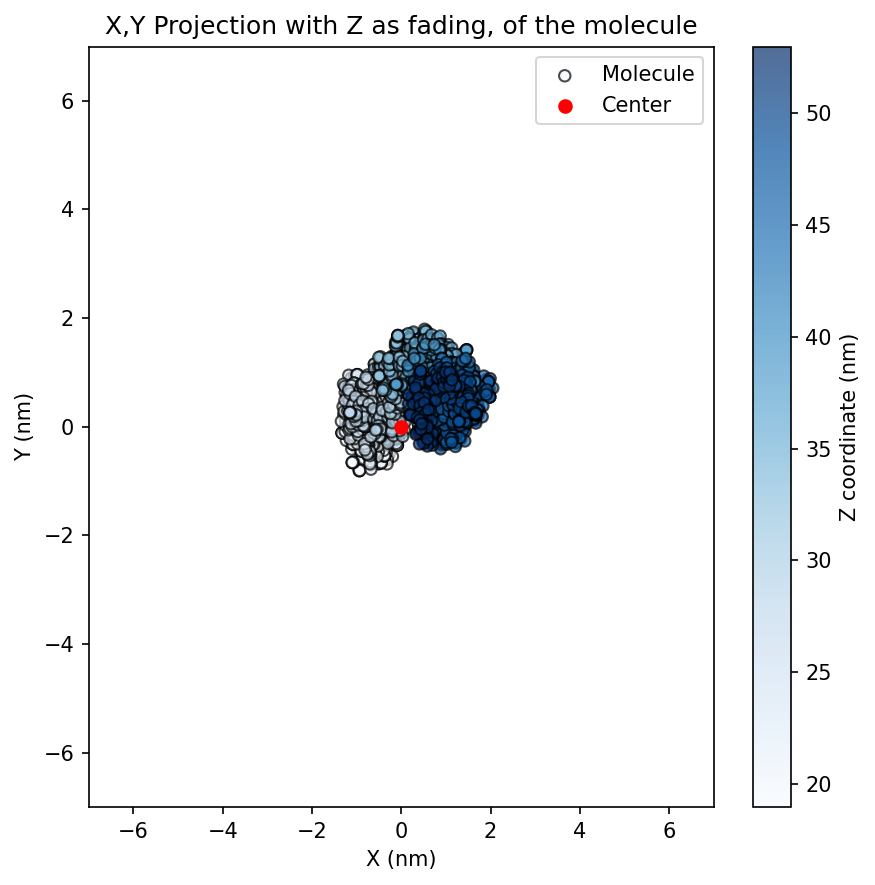

In [ ]:
# Top proyection
xm, ym, zm = molecule_mean_filt[:, 0], molecule_mean_filt[:, 1], molecule_mean_filt[:, 2]

plt.figure(figsize=(6,6), dpi=150)
sc = plt.scatter(xm, ym, c=zm, cmap='Blues', s=30, alpha=0.7, edgecolor='k', label='Molecule')
plt.scatter([0], [0], color='r', label='Center')

cbar = plt.colorbar(sc)
cbar.set_label("Z coordinate (nm)")

plt.xlabel("X (nm)")
plt.ylabel("Y (nm)")
plt.title("X,Y Projection with Z as fading, of the molecule")

plt.xlim((-7, 7))
plt.ylim((-7, 7))
plt.tight_layout()
plt.legend()
plt.show()